In [1]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-train.csv to Titanic-train (1).csv


In [2]:
import pandas as pd
import io
titanic_df = pd.read_csv(io.BytesIO(uploaded["Titanic-train.csv"]))
display(titanic_df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
titanic_df["Sex"].value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [4]:
# Data Visulaization
# https://matplotlib.org/stable/tutorials/colors/colormaps.html
import matplotlib.pyplot as plt

In [5]:
# Help
plt.pie?

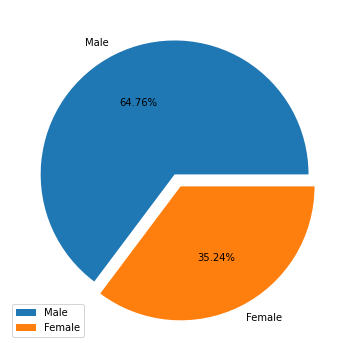

In [6]:
# Create a pie chart presenting the male/female proportion.
plt.figure(figsize = (6,8))
plt.pie(titanic_df["Sex"].value_counts(), autopct="%0.2f%%", labels=["Male", "Female"], explode=(0, 0.1))
plt.legend()
plt.show()

In [7]:
titanic_df["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [8]:
print("Survived = ", (titanic_df["Survived"]==1).sum())
print("Not Survived = ", (titanic_df["Survived"]==0).sum())

Survived =  342
Not Survived =  549


In [9]:
titanic_df.query("Survived==1 & Sex=='male'")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,NaN,C
55,56,1,1,"Woolner, Mr. Hugh",male,NaN,0,0,19947,35.5000,C52,S
...,...,...,...,...,...,...,...,...,...,...,...,...
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S
839,840,1,1,"Marechal, Mr. Pierre",male,NaN,0,0,11774,29.7000,C47,C
857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S


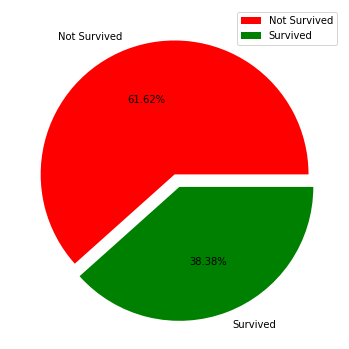

In [10]:
# Create a pie chart to present the surviving proportion.
plt.figure(figsize = (6,8))
plt.pie(titanic_df["Survived"].value_counts(), autopct="%0.2f%%", labels=["Not Survived", "Survived"], colors=["red", "green"], explode=(0, 0.1))
plt.legend()
plt.show()

In [11]:
titanic_df["Embarked"].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

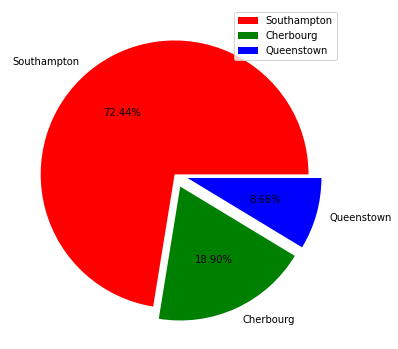

In [12]:
# Create a pie chart to present the port of embarkation.
plt.figure(figsize = (6,8))
plt.pie(titanic_df["Embarked"].value_counts(), autopct="%0.2f%%", labels=["Southampton","Cherbourg","Queenstown"], colors=['red','green','blue'], explode=(0.,0.1,0.1))
plt.legend()
plt.show()
# C = Cherbourg, Q = Queenstown, S = Southampton

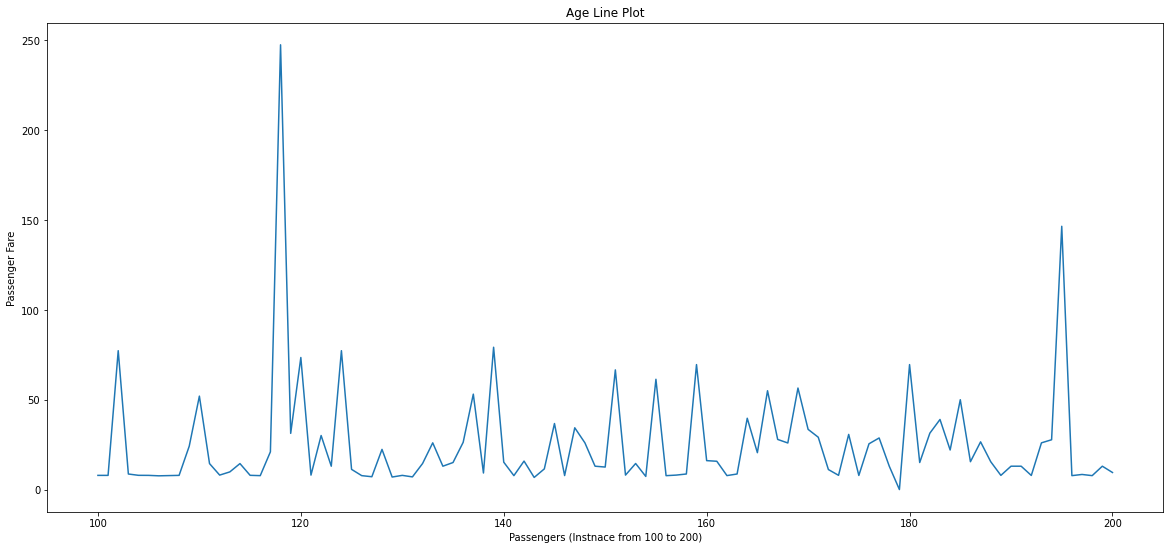

In [13]:
# Creating a line graph 
plt.figure(figsize=(20,9))
plt.plot(titanic_df.loc[100:200,['Fare']])
plt.title("Age Line Plot", fontsize = 12)
plt.xlabel("Passengers (Instnace from 100 to 200)")
plt.ylabel("Passenger Fare")
plt.show()

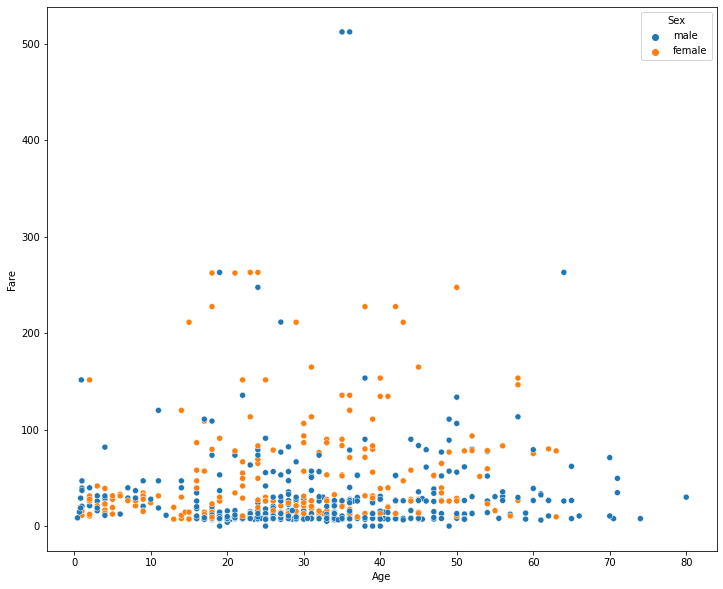

In [14]:
# Create a scatterplot with the Fare payed and the Age, differ the plot colour by gender.
import seaborn as sns # Data Distributional Plot 
plt.figure(figsize = (12,10))
sns.scatterplot(x="Age", y="Fare", hue="Sex", data=titanic_df)

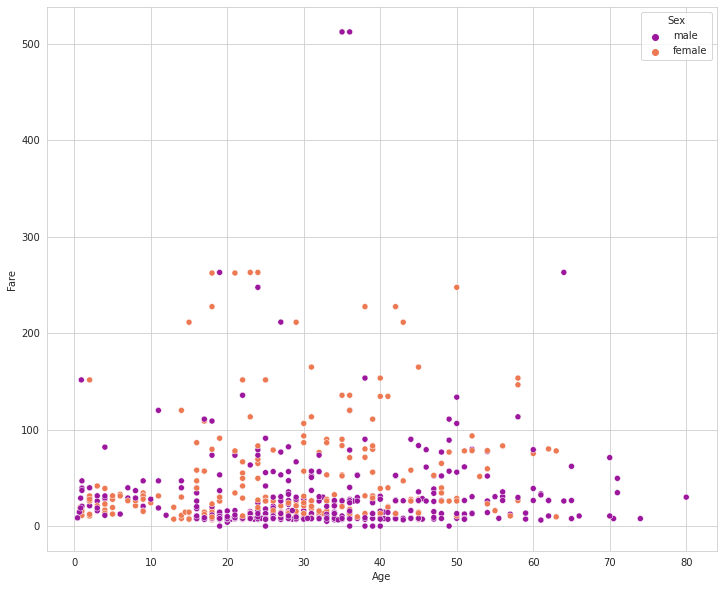

In [15]:
sns.set_style("whitegrid")
plt.figure(figsize = (12,10))
sns.scatterplot(x='Age', y='Fare', data=titanic_df, hue='Sex', palette='plasma')

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


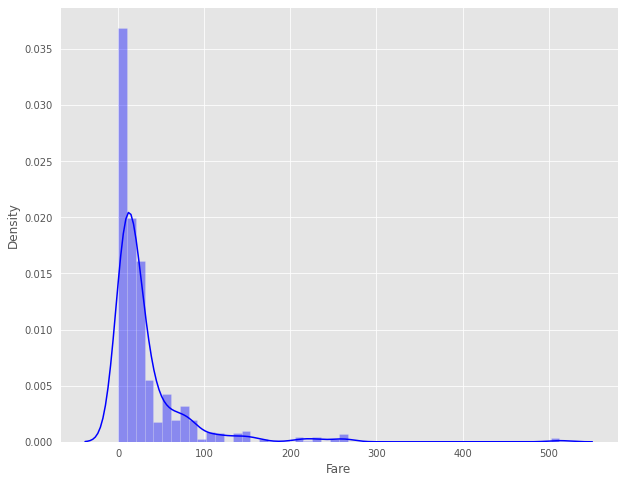

In [16]:
# Create a histogram with the Fare payed 
plt.style.use("ggplot")
plt.figure(figsize = (10,8))
sns.distplot(titanic_df["Fare"], color="blue")
# sns.distplot(titanic_train_df.Fare)
plt.show()

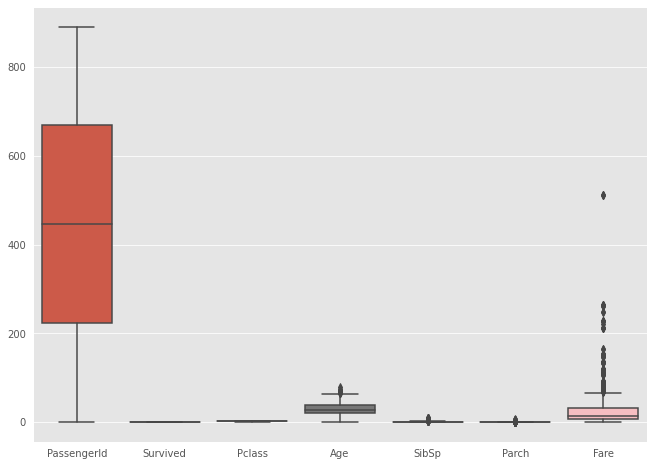

In [17]:
plt.style.use('ggplot')
plt.figure(figsize = (11,8))
sns.boxplot(data = titanic_df)

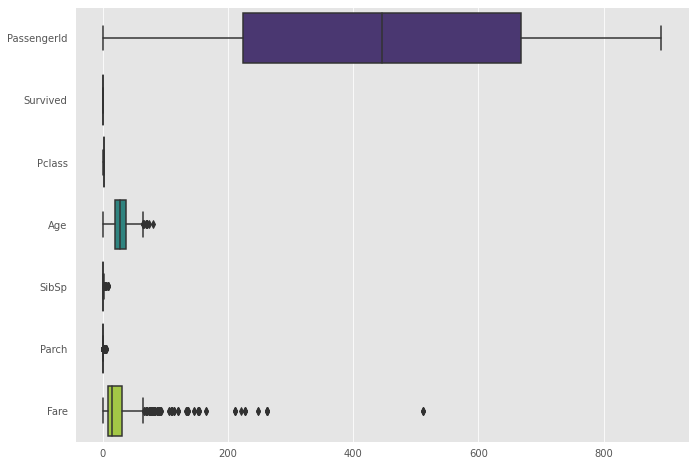

In [18]:
plt.style.use('ggplot')
plt.figure(figsize = (11,8))
sns.boxplot(data=titanic_df, orient='h', palette='viridis')

In [19]:
titanic_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


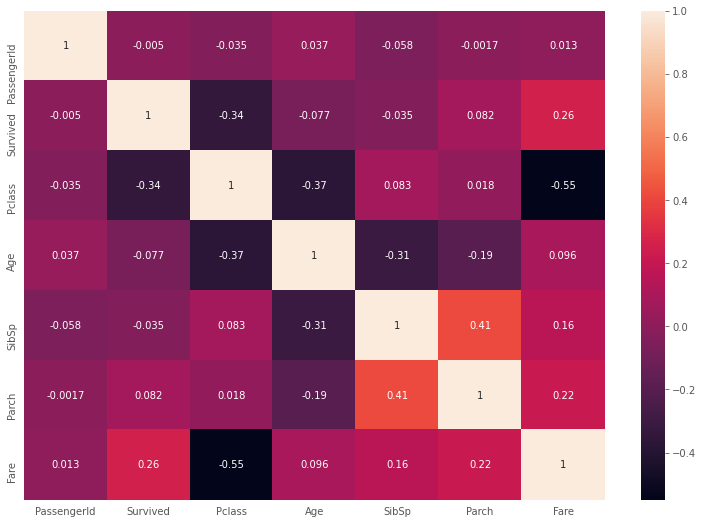

In [20]:
plt.figure(figsize = (13,9))
sns.heatmap(titanic_df.corr(), annot = True)

/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


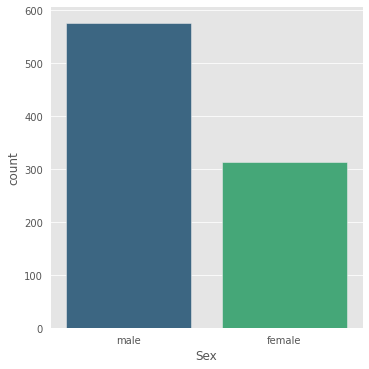

In [21]:
# Gender Plot
sns.factorplot('Sex', data=titanic_df, kind='count', palette='viridis')

/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


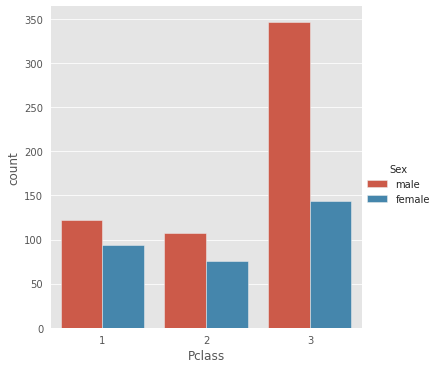

In [22]:
# Find the gender ration among the classes
sns.factorplot('Pclass', data=titanic_df, hue='Sex', kind='count')

/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


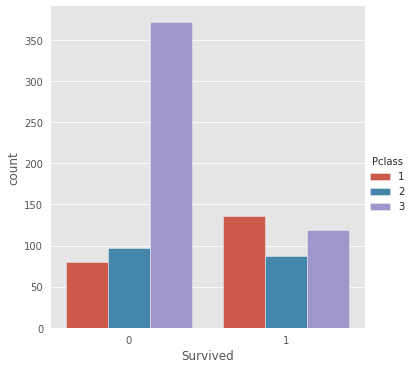

In [23]:
# Checking of the class had any effect in the survival rate
sns.factorplot('Survived', data=titanic_df, kind='count', hue='Pclass')

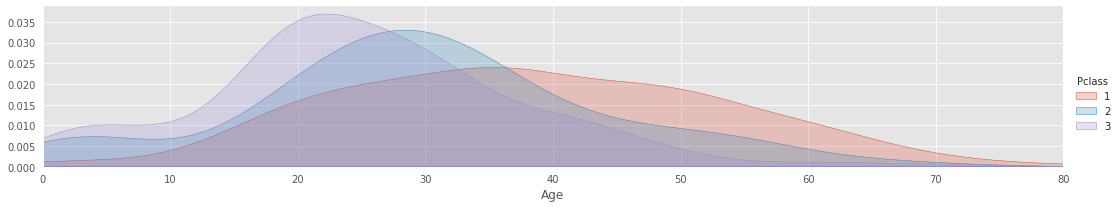

In [24]:
as_fig = sns.FacetGrid(titanic_df,hue='Pclass',aspect=5)
as_fig.map(sns.kdeplot,'Age',shade=True)
oldest = titanic_df['Age'].max()
as_fig.set(xlim=(0,oldest))
as_fig.add_legend()

/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


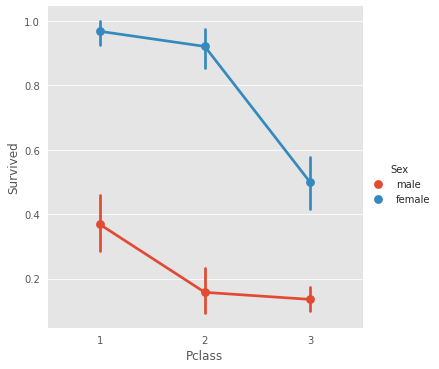

In [25]:
sns.factorplot('Pclass','Survived',data=titanic_df,hue='Sex')

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


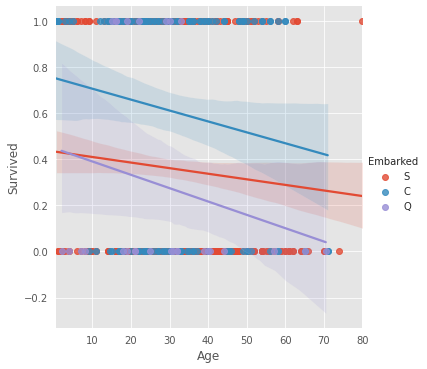

In [26]:
sns.lmplot('Age','Survived',data=titanic_df,hue='Embarked')

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


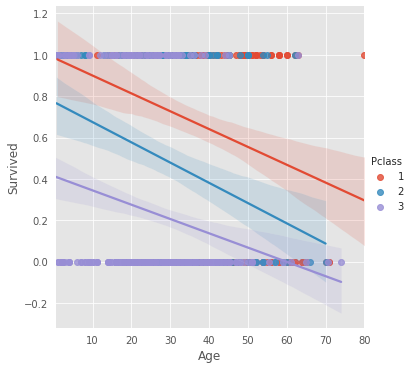

In [27]:
sns.lmplot('Age','Survived',data=titanic_df,hue='Pclass')

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


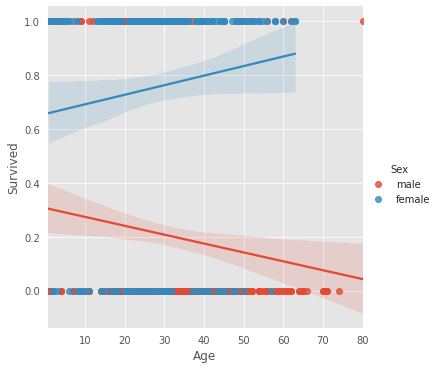

In [28]:
sns.lmplot('Age','Survived',data=titanic_df,hue='Sex')

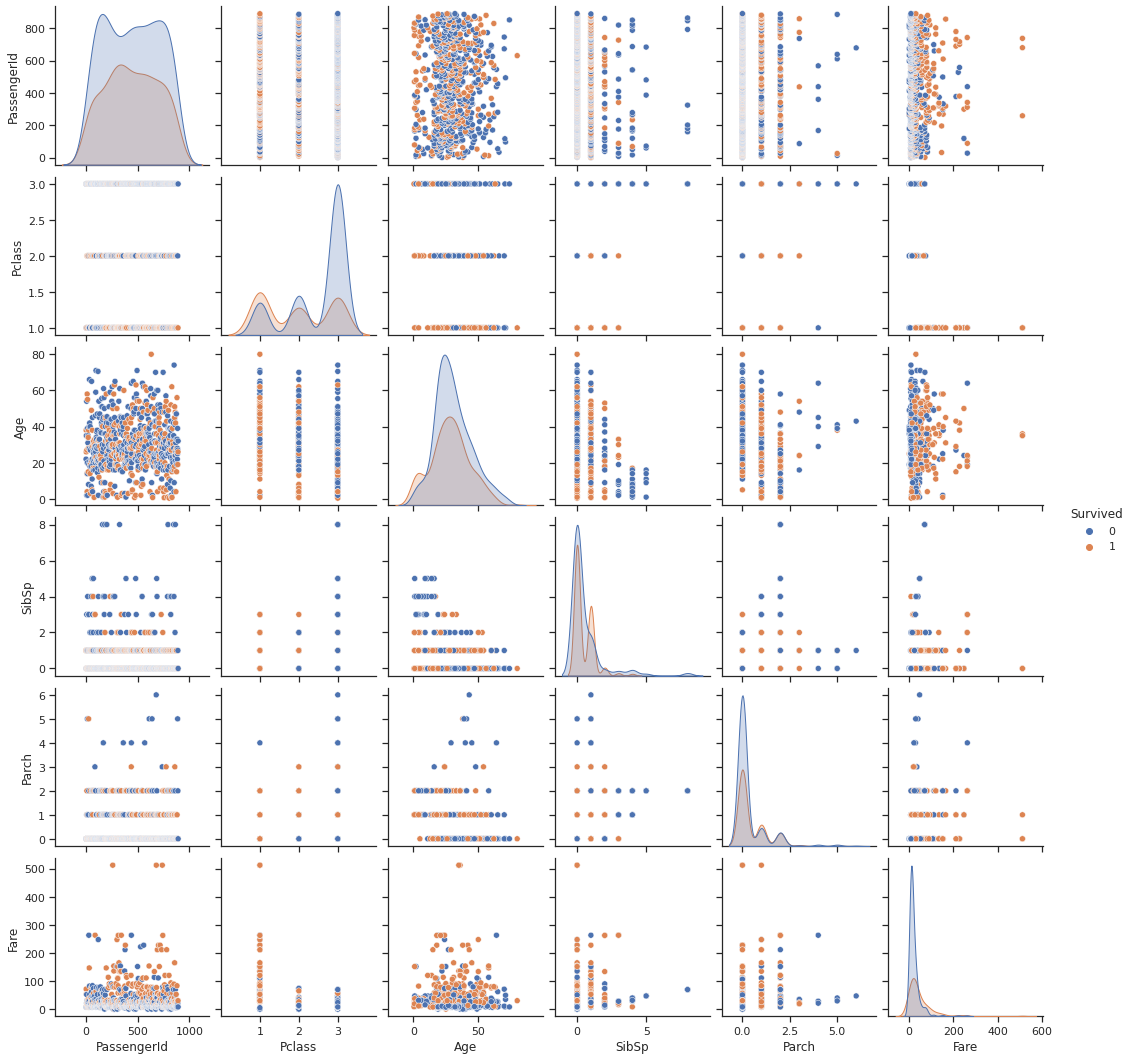

In [29]:
# Scatterplot Matrix
sns.set_theme(style="ticks")
# df = sns.load_dataset("penguins")
sns.pairplot(titanic_df, hue="Survived")

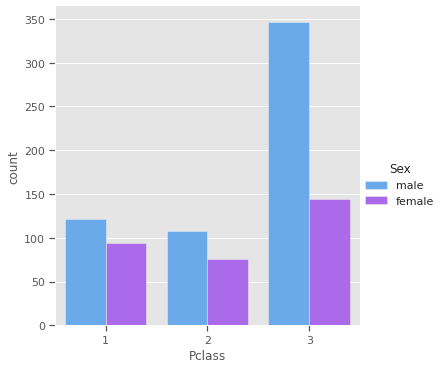

In [30]:
# Observation: Most of passengers travelling in 3rd Class 
plt.style.use("ggplot")
sns.catplot(x = 'Pclass', kind = "count", hue = 'Sex', data = titanic_df, palette='cool')
plt.show() 

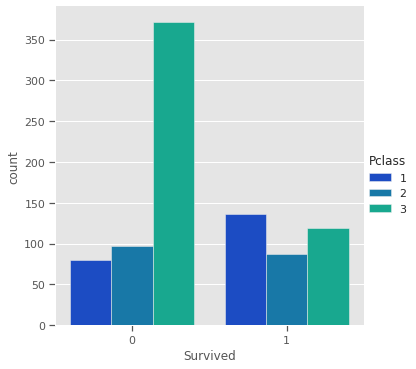

In [31]:
# Observation: Most of passengers travelling in 3rd Class 
plt.style.use("ggplot")
sns.catplot(x = 'Survived', kind = "count", hue = 'Pclass', data = titanic_df, palette = 'winter')
plt.show() 

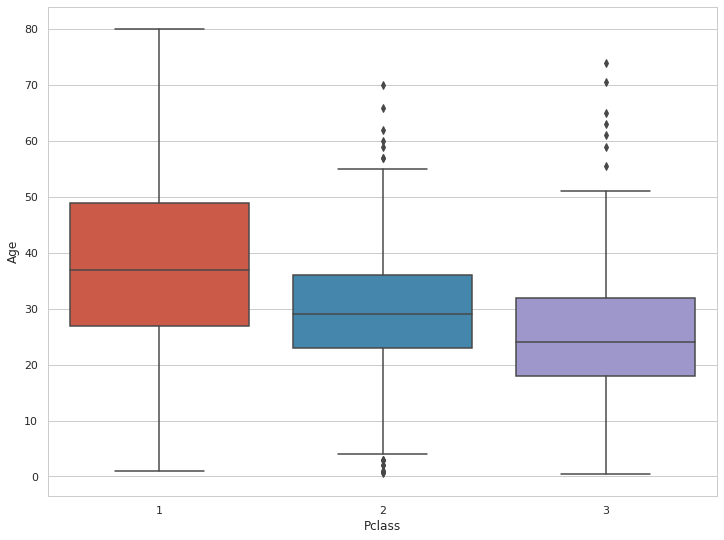

In [32]:
sns.set_style("whitegrid")
plt.figure(figsize = (12,9))
sns.boxplot(x = "Pclass", y = "Age", data = titanic_df)